In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

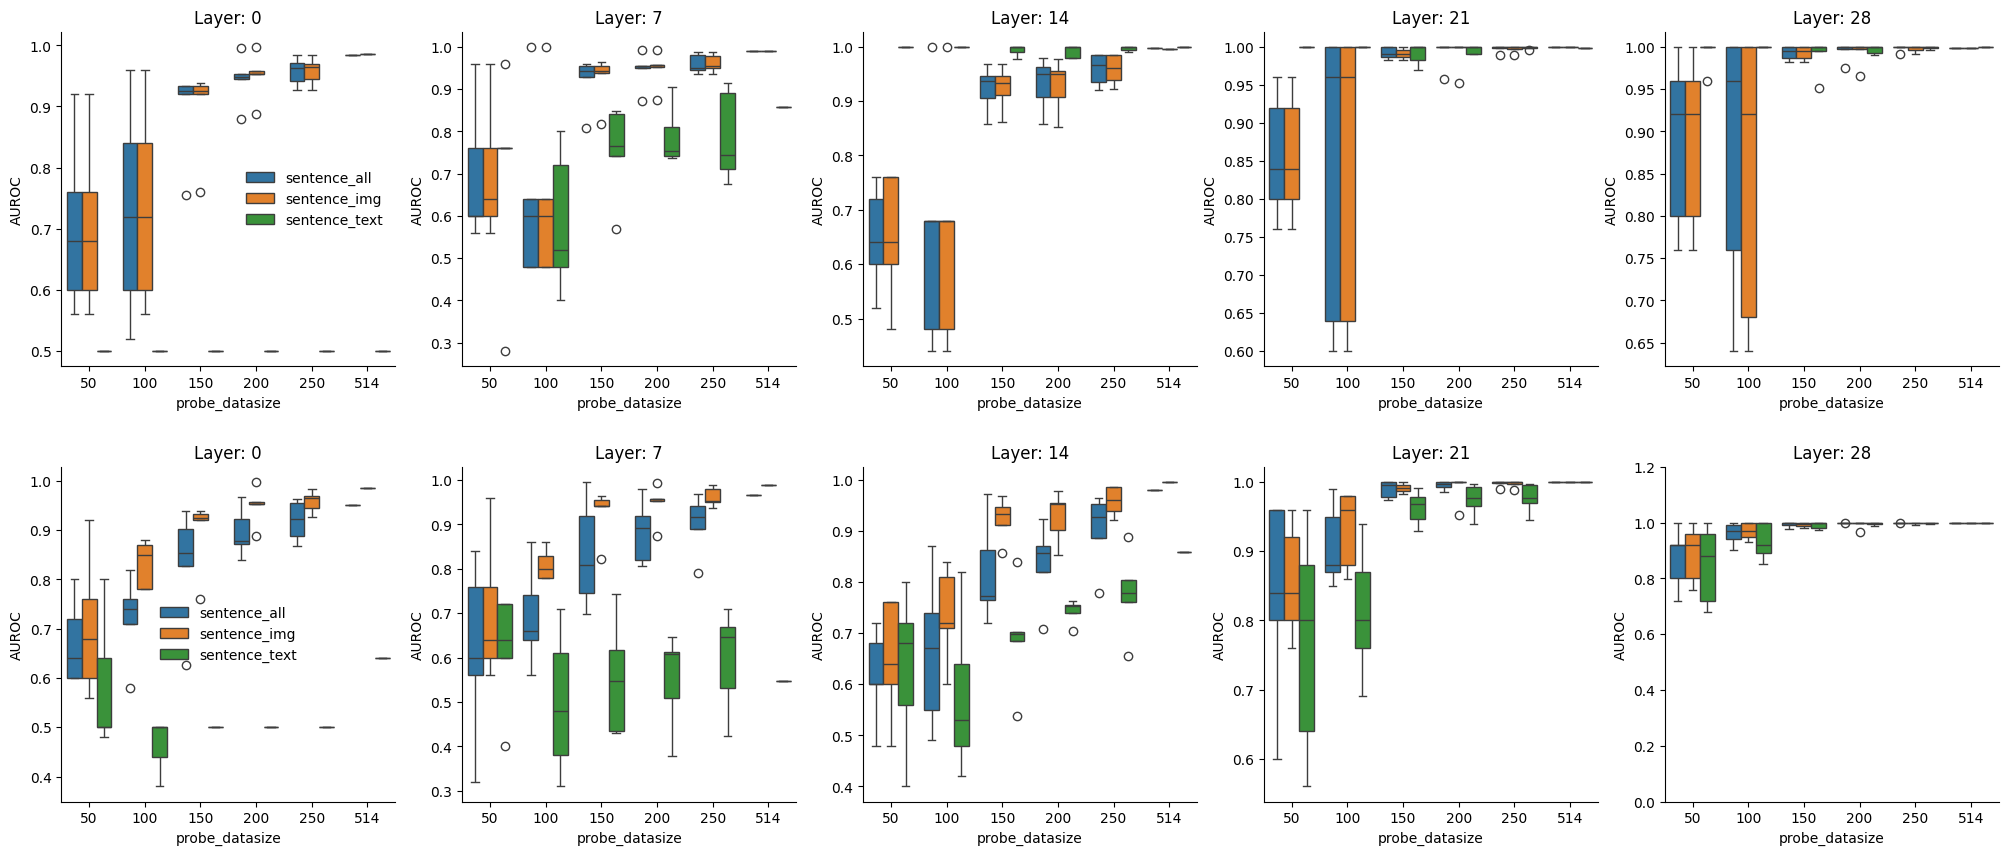

In [38]:
datasize_ls = [50,100,150,200,250,514]
layers = list(range(0,33,7))
metric = 'auroc'
prompt_type = ['simple', 'complex']
task = 'color'
target = 'red'
nobjects = 3

fig,axs = plt.subplots(nrows=2, ncols=len(layers), figsize=(5*len(layers), 5*len(prompt_type)))

plot_simple_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'./results/llava7B/linear_probing/probe_size/{prompt_type[0]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_simple_df = plot_simple_df + [df]
plot_simple_df = pd.concat(plot_simple_df)
plot_simple_df['embedding over'] = plot_simple_df['embedding_level'].apply(lambda x: x.split('_')[0])

plot_complex_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'./results/llava7B/linear_probing/probe_size/{prompt_type[1]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_complex_df = plot_complex_df + [df]
plot_complex_df = pd.concat(plot_complex_df)
plot_complex_df['embedding over'] = plot_complex_df['embedding_level'].apply(lambda x: x.split('_')[0])


for idx, layer in enumerate(layers):
    b = sns.boxplot(data=plot_simple_df[(plot_simple_df['layer']==layer) & (plot_simple_df['embedding over']=='sentence')], 
                    ax=axs[0][idx],
                    y=metric, x='probe_datasize', hue='embedding_level')
    b.set(title=f"Layer: {layer}")
    b.set_ylabel(metric.upper())
    
    if idx==0:
        b.legend(frameon=False)
    else:
        b.legend_.remove()

    b = sns.boxplot(data=plot_complex_df[(plot_complex_df['layer']==layer) & (plot_complex_df['embedding over']=='sentence')], 
                    ax=axs[1][idx],
                    y=metric, x='probe_datasize', hue='embedding_level')
    b.set(title=f"Layer: {layer}")
    b.set_ylabel(metric.upper())
    
    if idx==0:
        b.legend(frameon=False)
    else:
        b.legend_.remove()

sns.despine(top=True, right=True)
b.set(ylim=(0,1.2))
plt.subplots_adjust(hspace=0.3)

